In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [29]:

df = pd.read_csv("insurance.csv")

print(" Dataset Shape ")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n First 5 Rows ")
display(df.head())

print("\n Dataset Info ")
df.info()

print("\n Statistical Summary ")
display(df.describe())

print("\n Categorical Columns - Unique Values ")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

 Dataset Shape 
Rows: 1338, Columns: 7

 First 5 Rows 


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



 Dataset Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

 Statistical Summary 


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



 Categorical Columns - Unique Values 
sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [48]:

print(" Missing Values Per Column ")
print(df.isnull().sum())

print("\n Total Missing Values ")
print(df.isnull().sum().sum())

print("\n Duplicate Rows ")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found. Dataset is clean.")

 Missing Values Per Column 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

 Total Missing Values 
0

 Duplicate Rows 
Number of duplicate rows: 0
No duplicates found. Dataset is clean.


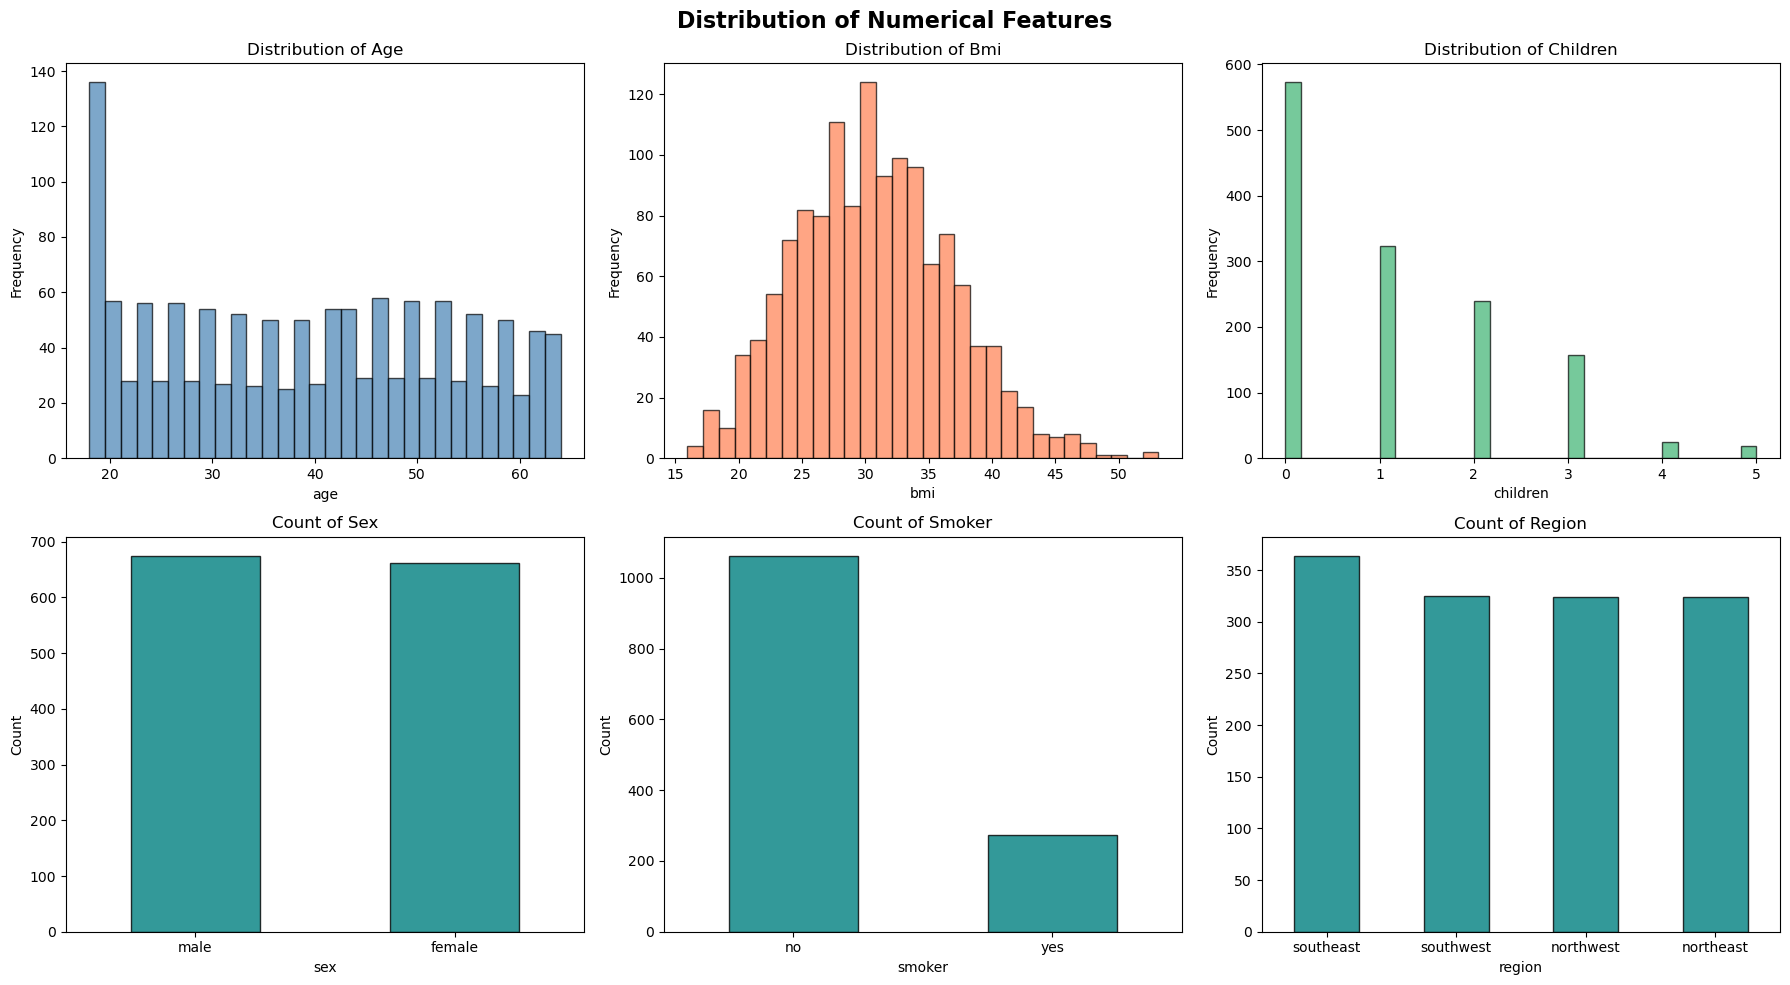

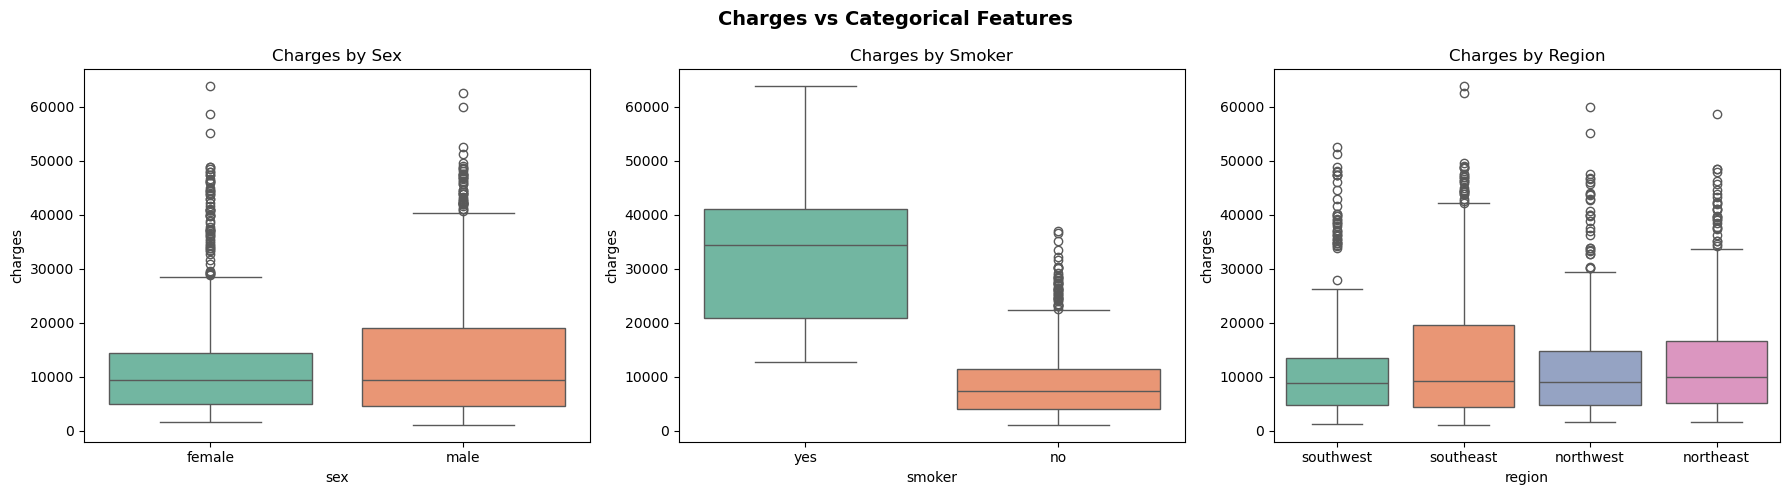

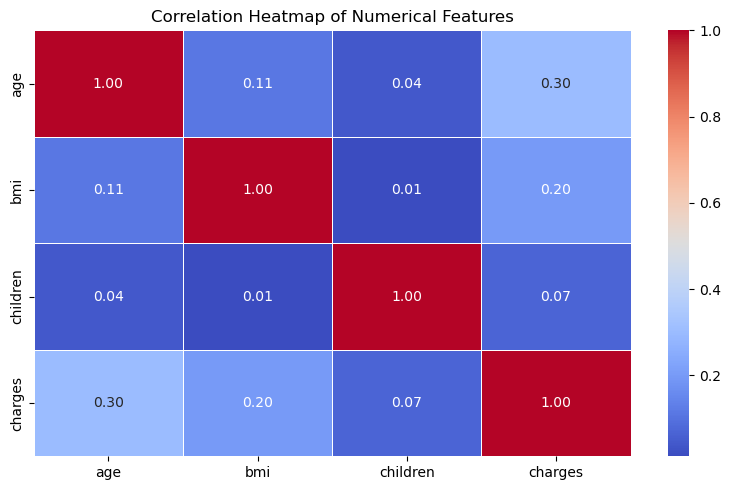

In [49]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distribution of Numerical Features", fontsize=16, fontweight='bold')

numerical_cols = ['age', 'bmi', 'children', 'charges']
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for i, col in enumerate(numerical_cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col.capitalize()}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')


for i, col in enumerate(['sex', 'smoker', 'region']):
    ax = axes[1][i]
    df[col].value_counts().plot(kind='bar', ax=ax, color='teal', edgecolor='black', alpha=0.8)
    ax.set_title(f'Count of {col.capitalize()}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Charges vs Categorical Features", fontsize=14, fontweight='bold')

for i, col in enumerate(['sex', 'smoker', 'region']):
    sns.boxplot(x=col, y='charges', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Charges by {col.capitalize()}')

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [50]:


df_encoded = df.copy()


le = LabelEncoder()

df_encoded['sex'] = le.fit_transform(df_encoded['sex'])
print(f"sex encoding: female=0, male=1")

df_encoded['smoker'] = le.fit_transform(df_encoded['smoker'])
print(f"smoker encoding: no=0, yes=1")


df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)
print(f"\nRegion one-hot encoded. New columns: {[c for c in df_encoded.columns if 'region' in c]}")

print("\n Encoded Dataset (First 5 Rows) ")
display(df_encoded.head())

print("\n Dataset Shape After Encoding ")
print(df_encoded.shape)

sex encoding: female=0, male=1
smoker encoding: no=0, yes=1

Region one-hot encoded. New columns: ['region_northwest', 'region_southeast', 'region_southwest']

 Encoded Dataset (First 5 Rows) 


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False



 Dataset Shape After Encoding 
(1337, 9)


In [51]:


X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print(" Features (X) ")
print(list(X.columns))
print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n=== Train/Test Split ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

 Features (X) 
['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

Feature Matrix Shape: (1337, 8)
Target Vector Shape: (1337,)

=== Train/Test Split ===
Training samples: 1069
Testing samples:  268


In [52]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Feature Scaling Applied ")
print("Method: StandardScaler (mean=0, std=1)")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")


scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\n Scaled Training Features (First 3 Rows) ")
display(scaled_df.head(3))

 Feature Scaling Applied 
Method: StandardScaler (mean=0, std=1)

X_train_scaled shape: (1069, 8)
X_test_scaled shape:  (268, 8)

 Scaled Training Features (First 3 Rows) 


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,-1.157680,0.971409,-0.996928,-0.907908,-0.500292,-0.572669,-0.605812,-0.57411
1,-1.300619,0.971409,-0.792762,0.766904,-0.500292,-0.572669,-0.605812,-0.57411
2,0.914926,-1.029432,1.154664,0.766904,-0.500292,1.746208,-0.605812,-0.57411


=== Linear Regression — Model Coefficients ===


,Feature,Coefficient
4,smoker,9234.342487
0,age,3472.975553
2,bmi,1927.828251
3,children,636.501185
1,sex,-50.749675
5,region_northwest,-168.944439
7,region_southwest,-284.610396
6,region_southeast,-371.780810



Intercept: 13030.20


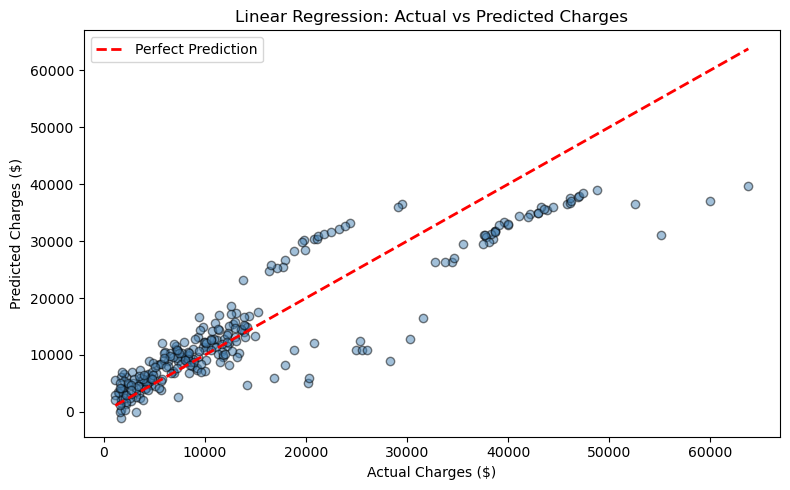

In [53]:

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("=== Linear Regression — Model Coefficients ===")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)
display(coef_df)

print(f"\nIntercept: {lr.intercept_:.2f}")


plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Linear Regression: Actual vs Predicted Charges")
plt.legend()
plt.tight_layout()
plt.show()

Best K (highest cross-val R²): 7


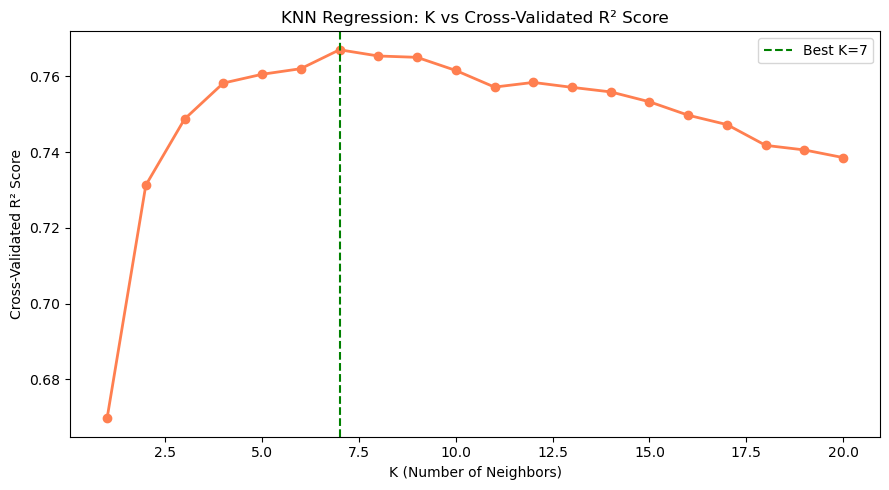

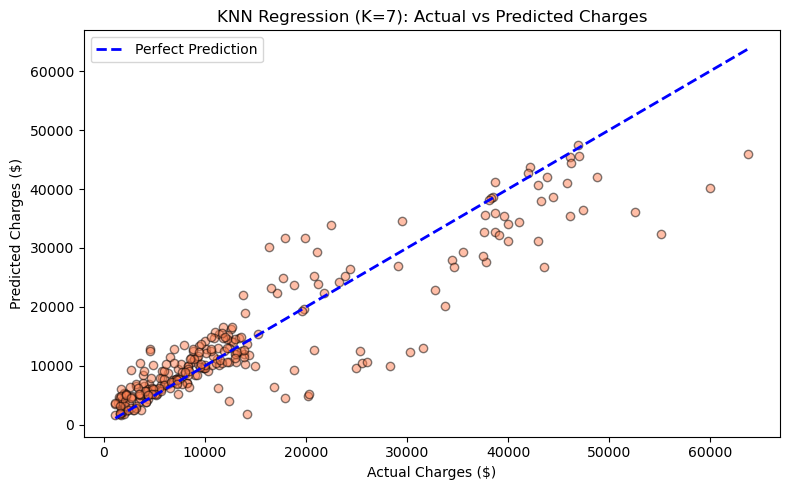

In [54]:

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn_cv = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f"Best K (highest cross-val R²): {best_k}")


plt.figure(figsize=(9, 5))
plt.plot(k_range, cv_scores, marker='o', color='coral', linewidth=2)
plt.axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Cross-Validated R² Score")
plt.title("KNN Regression: K vs Cross-Validated R² Score")
plt.legend()
plt.tight_layout()
plt.show()


knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)


plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_knn, alpha=0.5, color='coral', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title(f"KNN Regression (K={best_k}): Actual vs Predicted Charges")
plt.legend()
plt.tight_layout()
plt.show()

 Risk Tier Classification — Linear Regression 
              precision    recall  f1-score   support

         Low       0.83      0.83      0.83        60
      Medium       0.93      0.72      0.81        86
        High       0.77      0.89      0.83       122

    accuracy                           0.82       268
   macro avg       0.84      0.82      0.82       268
weighted avg       0.84      0.82      0.82       268

 Risk Tier Classification — KNN Regression 
              precision    recall  f1-score   support

         Low       0.86      0.83      0.85        60
      Medium       0.90      0.66      0.77        86
        High       0.75      0.90      0.82       122

    accuracy                           0.81       268
   macro avg       0.84      0.80      0.81       268
weighted avg       0.82      0.81      0.81       268



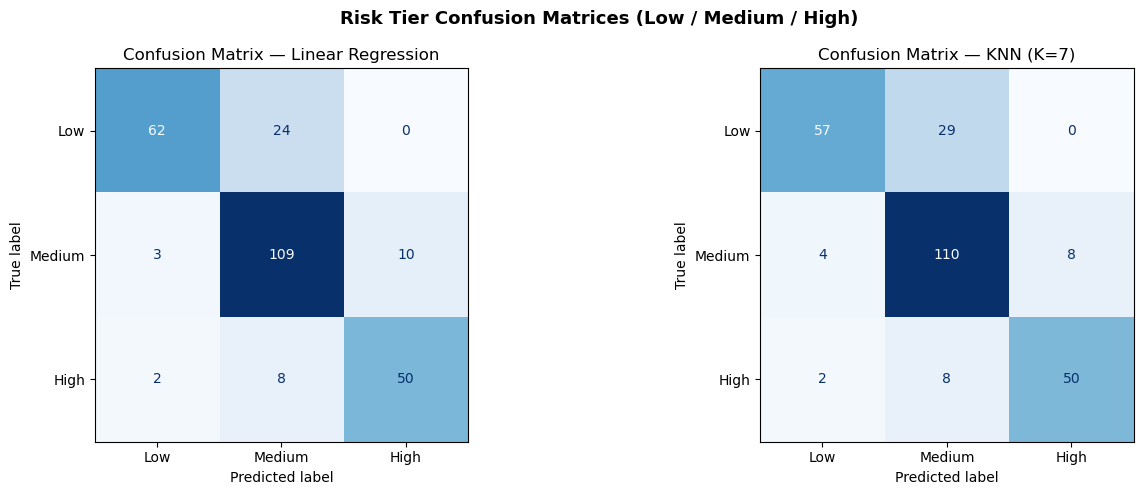

In [55]:

def assign_risk_tier(charge):
    if charge < 6000:
        return 'Low'
    elif charge < 20000:
        return 'Medium'
    else:
        return 'High'

y_test_tier = y_test.apply(assign_risk_tier)

# Assign risk tiers to predictions
y_pred_lr_tier = pd.Series(y_pred_lr).apply(assign_risk_tier)
y_pred_knn_tier = pd.Series(y_pred_knn).apply(assign_risk_tier)

tier_order = ['Low', 'Medium', 'High']

print(" Risk Tier Classification — Linear Regression ")
print(classification_report(y_test_tier, y_pred_lr_tier, target_names=tier_order))

print(" Risk Tier Classification — KNN Regression ")
print(classification_report(y_test_tier, y_pred_knn_tier, target_names=tier_order))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred_tier, model_name in zip(
    axes,
    [y_pred_lr_tier, y_pred_knn_tier],
    ['Linear Regression', f'KNN (K={best_k})']
):
    cm = confusion_matrix(y_test_tier, y_pred_tier, labels=tier_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tier_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}')

plt.suptitle("Risk Tier Confusion Matrices (Low / Medium / High)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [56]:

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
   
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  (Mean Absolute Error)      : ${mae:,.2f}")
    print(f"  MSE  (Mean Squared Error)       : ${mse:,.2f}")
    print(f"  RMSE (Root Mean Squared Error)  : ${rmse:,.2f}")
    print(f"  R²   (Coefficient of Det.)      : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results_lr  = evaluate_model("Linear Regression",     y_test, y_pred_lr)
results_knn = evaluate_model(f"KNN Regression (K={best_k})", y_test, y_pred_knn)

results_df = pd.DataFrame([results_lr, results_knn])
print("\n Summary Table ")
display(results_df.set_index('Model'))

  Linear Regression
  MAE  (Mean Absolute Error)      : $4,177.05
  MSE  (Mean Squared Error)       : $35,478,020.68
  RMSE (Root Mean Squared Error)  : $5,956.34
  R²   (Coefficient of Det.)      : 0.8069
  KNN Regression (K=7)
  MAE  (Mean Absolute Error)      : $3,604.12
  MSE  (Mean Squared Error)       : $31,497,423.56
  RMSE (Root Mean Squared Error)  : $5,612.26
  R²   (Coefficient of Det.)      : 0.8286

 Summary Table 


,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,4177.045561,3.547802e+07,5956.342894,0.806929
KNN Regression (K=7),3604.120934,3.149742e+07,5612.256548,0.828591


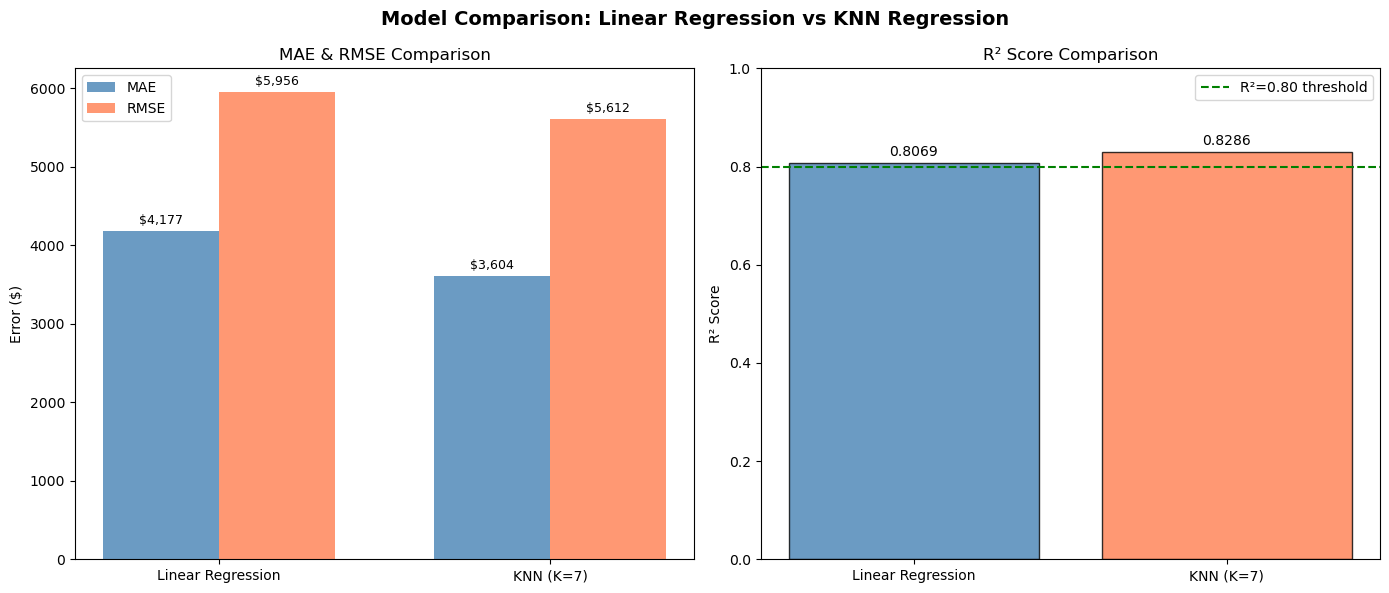

In [57]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['MAE', 'RMSE', 'R2']
colors_lr  = ['steelblue', 'steelblue', 'steelblue']
colors_knn = ['coral', 'coral', 'coral']


ax = axes[0]
x = np.arange(2)
bar_width = 0.35
mae_vals  = [results_lr['MAE'], results_knn['MAE']]
rmse_vals = [results_lr['RMSE'], results_knn['RMSE']]

bars1 = ax.bar(x - bar_width/2, mae_vals, bar_width, label='MAE', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + bar_width/2, rmse_vals, bar_width, label='RMSE', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Linear Regression', f'KNN (K={best_k})'])
ax.set_ylabel("Error ($)")
ax.set_title("MAE & RMSE Comparison")
ax.legend()
ax.bar_label(bars1, fmt='${:,.0f}', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='${:,.0f}', padding=3, fontsize=9)


ax2 = axes[1]
r2_vals = [results_lr['R2'], results_knn['R2']]
bar_colors = ['steelblue', 'coral']
bars = ax2.bar(['Linear Regression', f'KNN (K={best_k})'], r2_vals, color=bar_colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel("R² Score")
ax2.set_title("R² Score Comparison")
ax2.set_ylim(0, 1)
ax2.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax2.axhline(y=0.8, color='green', linestyle='--', label='R²=0.80 threshold')
ax2.legend()

plt.suptitle("Model Comparison: Linear Regression vs KNN Regression", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:

print("   FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)

winner = results_df.loc[results_df['R2'].idxmax(), 'Model']
loser  = results_df.loc[results_df['R2'].idxmin(), 'Model']

print(f"\n  Best Model (by R²): {winner}")
print(f"\n  {'Model':<30} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print(f"  {'-'*60}")
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<30} ${row['MAE']:>8,.0f} ${row['RMSE']:>8,.0f} {row['R2']:>8.4f}")



   FINAL MODEL COMPARISON SUMMARY

  Best Model (by R²): KNN Regression (K=7)

  Model                                 MAE       RMSE       R²
  ------------------------------------------------------------
  Linear Regression              $   4,177 $   5,956   0.8069
  KNN Regression (K=7)           $   3,604 $   5,612   0.8286
